# Gender Analysis

Identifies litigant gender from the opening ~100 characters of each case using jieba tokenization. Exports summary and visualizes the male/female split.

# Imports & Load Data

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import jieba
import os
import re

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [12]:
df = pd.read_csv("../data/01_filtered_cases.csv")
df.head()
df.iloc[0].full_text

,case_name,case_type,court,date,case_href,full_text,litigant_type
0,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原...,individual
1,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,山东省高级人民法院\n民 事 裁 定 书\n（2021）鲁民申3670号\n再审申请人（一审...,individual
2,马晓三、云南省人民检察院劳动争议再审民事判决书,民事再审,云南省高级人民法院,2020-06-09,https://wenshu.court.gov.cn/website/wenshu/181...,云南省高级人民法院\n民 事 判 决 书\n（2019）云民再30号\n抗诉机关：云南省人民...,individual
3,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,北京市高级人民法院\n民 事 裁 定 书\n（2020）京民申2236号\n再审申请人（一审...,individual
4,马俊岭等十三人故意伤害二审刑事附带民事判决书,刑事二审,陕西省高级人民法院,2018-07-30,https://wenshu.court.gov.cn/website/wenshu/181...,陕西省高级人民法院\n刑 事 附 带 民 事 判 决 书\n（2018）陕刑终147号\n原...,individual


'吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原告、二审上诉人）：刘慷，男，1968年8月22日出生，汉族，现住吉林省长春市。\n委托诉讼代理人:付文龙，吉林中昱律师事务所律师。\n被申请人（一审被告、二审被上诉人）：吉林省射击射箭运动管理中心，住所地吉林省长春市。\n法定代表人：王宝宏，该中心主任。\n委托诉讼代理人：由龙运，吉林智迪律师事务所律师。\n再审申请人刘慷因与被申请人吉林省射击射箭运动管理中心（以下简称射击射箭中心）人事争议一案，不服吉林省长春市中级人民法院(2020)吉01民终5748号民事判决，向本院申请再审。本院于2021年8月13日作出（2021）吉民申2428号民事裁定，提审本案。本院依法组成合议庭审理了本案。本案现已审理终结。\n刘慷申请再审称，一、请求贵院依法撤销吉林省长春市绿园区人民法院作出的（2020）吉0106民初2096号民事判决书及吉林省长春市中级人民法院作出的（2020）吉01民终5748号民事判决书。二、请求贵院依法改判恢复申请人与被申请人之间的人事关系。三、一、二审诉讼费由被申请人承担。事实与理由：一、原审法院认定事实不清，证据不足。原审法院仅依据吉林省第二体工队于1992年3月18日作出的《关于孙吉相等5名队员的转业报告》、调令、离校通知书、工资发放表，从而认定二者之间的人事关系已经解除，属于明显的认定事实不清。第一，《关于孙吉相等5名队员的转业报告》，申请人认为该份报告仅能证明吉林省第二体工队于当年向省体委人事处就包括申请人在内的五名运动员转业事宜进行报批的事实，若该请示已经得到批复，被申请人应提交相应的证据予以证明，但被申请人在原审中并未提交省体委人事处或其上级部门就上述报批事宜任何的书面文件批复，因此，该份报告并未生效，更未实际履行。第二，关于被申请人提交的申请人离队手续及调令，原审法院认定，1992年9月27日申请人在吉林省第二体工队各部门办理了离队手续，同时已为申请人开具调令，安置到长春市机械工业研究所工作。首先，申请人本人并没有办理任何离队手续，其次，吉林省第二体工队第012号离校通知书中并没有标明具体日期，第013号的调令中没有单位的公章，上述两份材料也没有申请人本人签字，日期也并非是9月27日，原审法院认定被申请人为申请人于9月27日办理了相关调令没有任何事实

# Add gender metrics

indicated by their name (AND GENDER) being present in the opening line of the case text. filtering is achieved by dropping case entries where gender count of the opening line (approx. 100 characters) is 0, indicating it is a company or institution, and not the athlete.

In [37]:
# add gender metrics
def extract_litigant_line(text):
    match = re.search(r'(?:[^\n]+\n){3}([^\n]+)', text) # get two line. RE: (?:) match but don't record
    return match.group(1) if match else None

def count_words(text):
    words = jieba.lcut(text)
    female_count = sum(1 for w in words if w == '女')
    male_count = sum(1 for w in words if w == '男')
    if (female_count + male_count == 0):
        return None
    return female_count, male_count

df["litigant_line"] = df["full_text"].apply(extract_litigant_line)
df["litigant_line"]

df[['female_count', 'male_count']] = df['litigant_line'].apply(lambda x: pd.Series(count_words(x)))
df.head()

0      再审申请人（一审原告、二审上诉人）：刘慷，男，1968年8月22日出生，汉族，现住吉林省长春市。
1     再审申请人（一审被告、二审被上诉人）：刘小宝，男，1981年9月27日出生，汉族，住山东省济...
2                                         抗诉机关：云南省人民检察院
3       再审申请人（一审原告、二审上诉人）：李素萍，女，1966年3月4日出生，汉族，住北京市丰台区。
4                                        原公诉机关西安市人民检察院。
                            ...                        
74                                 起诉人詹x，男，1955年3月9日出生。
75                           原告纪程（曾用名纪敏），女，汉族，现住白山市浑江区.
76                      原告王珏，男，汉族，1964年10月9日出生，住成都市高新区。
77                                              原告：胡容儿。
78                                                原告李雁。
Name: litigant_line, Length: 79, dtype: object

,case_name,case_type,court,date,case_href,full_text,litigant_type,litigant_line,female_count,male_count
0,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原...,individual,再审申请人（一审原告、二审上诉人）：刘慷，男，1968年8月22日出生，汉族，现住吉林省长春市。,0.0,1.0
1,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,山东省高级人民法院\n民 事 裁 定 书\n（2021）鲁民申3670号\n再审申请人（一审...,individual,再审申请人（一审被告、二审被上诉人）：刘小宝，男，1981年9月27日出生，汉族，住山东省济...,0.0,1.0
2,马晓三、云南省人民检察院劳动争议再审民事判决书,民事再审,云南省高级人民法院,2020-06-09,https://wenshu.court.gov.cn/website/wenshu/181...,云南省高级人民法院\n民 事 判 决 书\n（2019）云民再30号\n抗诉机关：云南省人民...,individual,抗诉机关：云南省人民检察院,NaN,NaN
3,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,北京市高级人民法院\n民 事 裁 定 书\n（2020）京民申2236号\n再审申请人（一审...,individual,再审申请人（一审原告、二审上诉人）：李素萍，女，1966年3月4日出生，汉族，住北京市丰台区。,1.0,0.0
4,马俊岭等十三人故意伤害二审刑事附带民事判决书,刑事二审,陕西省高级人民法院,2018-07-30,https://wenshu.court.gov.cn/website/wenshu/181...,陕西省高级人民法院\n刑 事 附 带 民 事 判 决 书\n（2018）陕刑终147号\n原...,individual,原公诉机关西安市人民检察院。,NaN,NaN


In [47]:
# remove NaN values from df to create df_1
df_1 = df[ ~(df.female_count.isna() & df.male_count.isna()) ]

print("number of cases with no gender marker: ", df.shape[0] - df_1.shape[0])
print("number of cases kept: ", df_1.shape[0])

df_1.head()

number of cases with no gender marker:  21
number of cases kept:  58


,case_name,case_type,court,date,case_href,full_text,litigant_type,litigant_line,female_count,male_count
0,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原...,individual,再审申请人（一审原告、二审上诉人）：刘慷，男，1968年8月22日出生，汉族，现住吉林省长春市。,0.0,1.0
1,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,山东省高级人民法院\n民 事 裁 定 书\n（2021）鲁民申3670号\n再审申请人（一审...,individual,再审申请人（一审被告、二审被上诉人）：刘小宝，男，1981年9月27日出生，汉族，住山东省济...,0.0,1.0
3,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,北京市高级人民法院\n民 事 裁 定 书\n（2020）京民申2236号\n再审申请人（一审...,individual,再审申请人（一审原告、二审上诉人）：李素萍，女，1966年3月4日出生，汉族，住北京市丰台区。,1.0,0.0
6,李某猛、某商业保理有限公司）、原审第三人某二有限公司教育培训合同纠纷二审民事判决书,民事二审,重庆市第一中级人民法院,2026-02-27,https://wenshu.court.gov.cn/website/wenshu/181...,重庆市第一中级人民法院\n民 事 判 决 书\n（2025）渝01民终13121号\n上诉人...,individual,上诉人（原审被告）：李某猛，男，汉族，住河南省。,0.0,1.0
8,陈某翔与黄某铭民间借贷纠纷二审民事判决书,民事二审,广西壮族自治区南宁市中级人民法院,2024-12-15,https://wenshu.court.gov.cn/website/wenshu/181...,广西壮族自治区南宁市中级人民法院\n民 事 判 决 书\n（2024）桂01民终10765号...,individual,上诉人（原审被告）：陈某翔，男，1988年6月15日出生，汉族，住南宁市青秀区。,0.0,1.0


# Pie: Litigant Gender Differences

In [43]:
plotdf_gender = df_1[["female_count", "male_count"]].sum()
plotdf_gender

female_count    19.0
male_count      42.0
dtype: float64

In [45]:
plotdf_gender.to_csv("../output/gender_dif.csv", index = False)
print(f"output CSV file saved to {os.getcwd()}")

output CSV file saved to /Users/wyx/Library/CloudStorage/OneDrive-DartmouthCollege/qss20_athlete_court_complaints/code


([<matplotlib.patches.Wedge at 0x158df5590>,
 [Text(0.6140680961312414, 0.9126447136283389, 'Female'),
  Text(-0.6140681251410309, -0.9126446941092571, 'Male')],
 [Text(0.3349462342534043, 0.49780620743363935, '31.1%\n(19)'),
  Text(-0.33494625007692597, -0.49780619678686744, '68.9%\n(42)')])

Text(0.5, 0.98, 'Litigant Gender Identification:\n Female athletes are 38% less visible judicially')

Text(0.5, 0.05, '# out of 61 ligitants in 58 identified cases')

Text(0.5, 0.01, 'Source: China Judgements Online')

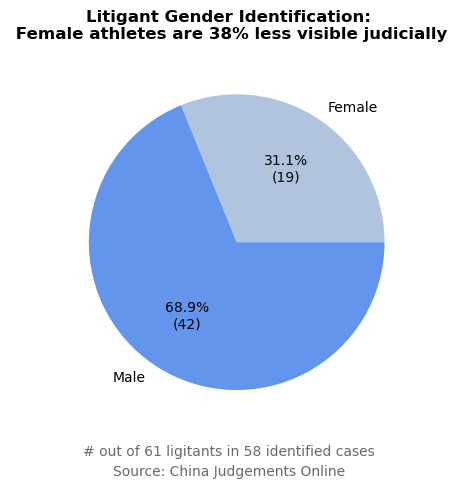

In [54]:
fig, ax = plt.subplots()
    # fig (Figure) — entire canvas/window
    # ax (Axes) — actual plot area inside the frame where data is drawn

labels = ['Female', 'Male']
colors = ['lightsteelblue', 'cornflowerblue']
ax.pie(
    plotdf_gender,
    labels = labels,
    colors = colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * plotdf_gender.sum() / 100))})",
)

fig.suptitle("Litigant Gender Identification:\n Female athletes are 38% less visible judicially", fontsize=12, fontweight="bold")

fig.text(0.5, 0.05, "# out of 61 ligitants in 58 identified cases", fontsize=10, color="dimgray",
         ha="center")
fig.text(0.5, 0.01, "Source: China Judgements Online", fontsize=10, color="dimgray",
         ha="center")


# fig.savefig("../output/gender_dif.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()